### Introduction
In this phase, I focus on understanding the Titanic dataset before building any machine learning models. The goal is not just to load the data, but to carefully examine its structure, patterns, and potential issues.

This step is important because later modeling decisions should be based on what the data actually shows rather than assumptions.

Following the CRISP-DM framework [1], I organize this phase into four main steps:

1. **Data Collection**: Load the dataset and confirm it is accessible and correctly structured.
2. **Data Description**: Inspect the dataset structure, variable types, and summary statistics.
3. **Data Exploration**: Use visualizations and descriptive analysis to look for patterns related to survival.
4. **Data Quality Verification**: Check for missing values, duplicates, outliers, and inconsistencies.

The Titanic disaster is often described as a natural experiment in human behavior during extreme situations [2]. Historical accounts suggest that factors such as gender, class, and age influenced survival. Using exploratory data analysis techniques [3], I examine whether these patterns appear in the dataset and use the findings to guide later modeling steps.

### Research Questions & Hypotheses

Based on historical studies and prior research, I investigate several questions about survival on the Titanic.

1. **Class Disparities**
*Did passenger class influence survival outcomes? - (RQ1).*
Historical evidence suggests that first-class passengers may have had better access to lifeboats [6]. I therefore expect higher survival rates for first-class passengers compared with third-class passengers.


2. **Age Priority**
*Did younger passengers have better survival chances? - (RQ2).*
Research on behavior in crisis situations suggests that age may influence survival, although the effect might vary across passenger classes [2].

3. **Family Effects**
*Did traveling with family affect survival chances? - (RQ3).*
Passengers traveling in groups may have been able to coordinate evacuation, but larger groups may also have faced difficulties moving quickly.

4. **Gender Priority**
*Was the “women and children first” principle followed during evacuation?  - (RQ4).*
Historical research suggests that female passengers had higher survival chances than male passengers [2], [6].

These questions guide my exploration of the dataset.

### 1. Collect Initial Data

The first step is to load the Titanic dataset into the Python environment. Even though this step is simple, it helps confirm that the dataset is available and correctly formatted.

I use the Pandas library, which is widely used for handling tabular data and DataFrame structures [5].

The dataset is stored in the project directory and contains passenger information such as age, ticket fare, passenger class, and survival outcome.

After loading the dataset, I check the first few rows to verify that:

- The dataset loads correctly
- The columns appear as expected
- The data structure matches the project requirements

This quick preview also helps me understand what kind of information is available for analysis. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np

from titanic_surv.dataset import load_data

# Load the Titanic dataset
data = load_data("titanic.csv")

# Display basic statistics for numeric columns
print(data.head())

# print Confirmation
print("\nBy loading the dataset, I can:") 
print("- Confirm that the data is accessible and correctly formatted.")
print("- Preview the first few records to understand the structure and type of information available. !")

2026-03-13 23:38:41.241 | INFO     | titanic_surv.config:<module>:11 - PROJ_ROOT path is: D:\py\Titanic\titanic_surv_pred_insights


   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0       1        0        0       0.0   
2       0  ...        0        0        0       3        0        0       2.0   
3       0  ...        0        0        0       1        0        0       2.0   
4       0  ...        0        0        0       3        0        0       2.0   

   zero.17  zero.18  2urvived  
0        0        0         0 

### 2. Describe Data

In this step, I examine the dataset structure and summary statistics to understand the characteristics of each variable.

This helps me:

- Identify numerical and categorical variables
- Understand the range and distribution of values
- Check whether data types are assigned correctly
- Inspect the balance of the target variable (Survived)

Understanding the dataset structure early helps avoid mistakes later in the modeling process.

#### 2.1 Dataset Structure and Variables

The dataset contains 1309 passenger records and 28 columns.

The variables include passenger identifiers, demographic characteristics, family information, ticket fare, and the survival outcome.

Checking column names helps identify useful variables and detect potential issues such as unnecessary or placeholder columns. Some columns beginning with “zero” appear to contain no meaningful information and will likely be removed in the data preparation phase.

In [2]:
# Display column names
data.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [3]:
data.shape

(1309, 28)

#### 2.2 Data Types Inspection

Next, I examine the data types of each variable.

This step is important because machine learning algorithms typically require numerical inputs. Categorical variables may need to be encoded before modeling [3].

From the inspection:
- Age and Fare are stored as floating-point numbers.
- PassengerId, Pclass, SibSp, and Parch are integers.
- Embarked is stored as a numeric category.

Checking data types also helps confirm that variables are being interpreted correctly by the analysis tools.

In [4]:
# Inspect data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

#### 2.3 Descriptive Statistics

To better understand the dataset, I calculate descriptive statistics such as mean, standard deviation, minimum, maximum, and quartiles.

Exploratory statistics help reveal how the data is distributed before building models. *Tukey (1977)* emphasizes that examining data distributions is a key step before any statistical modeling [4].

Some observations from the summary statistics:
- Age has a wide range, from infants to elderly passengers.
- Fare shows a strong right-skewed distribution. Most passengers paid relatively low fares, while a small number paid extremely high ticket prices.

This skew suggests strong economic differences among passengers and may influence survival outcomes.

In [5]:
# Descriptive statistics for numerical columns
data.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


In summary:
- **Age**: The ages are pretty evenly spread out, meaning I have a good mix of people. Since the data is balanced, I can use it as-is once I fill in all blanks.

- **Fare**: This is lopsided. Most people paid very little, but a few paid a fortune. This "skew" shows a big wealth gap and means I might need to adjust or group these numbers later so the extreme high prices don't mess up the model.

#### 2.4 Target Variable Identification and Correction

During the inspection process, I noticed that the survival column in the raw dataset is labeled “2urvived.”

Based on the dataset context, this appears to be a typographical error. To maintain consistency, I rename this column to “Survived.”

The target variable represents passenger survival:
- 0 = Did not survive
- 1 = Survived

I also check the class distribution to determine whether the dataset is balanced.

The results show:
- 967 passengers did not survive
- 342 passengers survived

This means that about 74% of passengers died and 26% survived, which indicates a class imbalance. When datasets are imbalanced, evaluation metrics such as precision, recall, and F1-score are often more informative than accuracy alone [3].

In [6]:
# Rename inconsistent or incorrect column names
data = data.rename(columns={
    "Passengerid": "PassengerId",
    "sibsp": "SibSp",
    "2urvived": "Survived"
})

# Verify the fix
data.columns

Index(['PassengerId', 'Age', 'Fare', 'Sex', 'SibSp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', 'Survived'],
      dtype='object')

In [7]:
# Class distribution of the target variable
data["Survived"].value_counts()

Survived
0    967
1    342
Name: count, dtype: int64

In [8]:
# Percentage distribution
print("Survival Percentage")
print(data["Survived"].value_counts(normalize=True) * 100)


Survival Percentage
Survived
0    73.873186
1    26.126814
Name: proportion, dtype: float64


#### 2.5 Summary Statistics Table

Below is a structured summary of key numerical variables relevant to survival prediction:

In [9]:
# Select key numerical columns
key_features = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

data[key_features].describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,0.261268,2.294882,29.503186,0.498854,0.385027,33.281086
std,0.439494,0.837836,12.905241,1.041658,0.865560,51.741500
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


### 3. Explore Data

In this section, I perform exploratory data analysis (EDA) to investigate patterns in the dataset.

The goal is to examine how passenger characteristics relate to survival outcomes. This step helps identify features that may be useful for prediction. [2]

The analysis focuses on:
- Overall survival distribution
- Survival differences across passenger classes
- Survival differences between genders
- Age distribution patterns
- Effects of family size
- Relationship between ticket fare and survival

Exploratory analysis helps test whether patterns suggested by historical research appear in the dataset.

#### 3.1 Survival Distribution

I start by examining the overall distribution of survival outcomes.

The results show that the dataset is imbalanced, with a much larger number of passengers who did not survive.

As discussed in machine learning literature, class imbalance can affect evaluation metrics and model performance [3]. Because of this, later evaluation will rely on metrics such as F1-score and AUC rather than accuracy alone. [4]

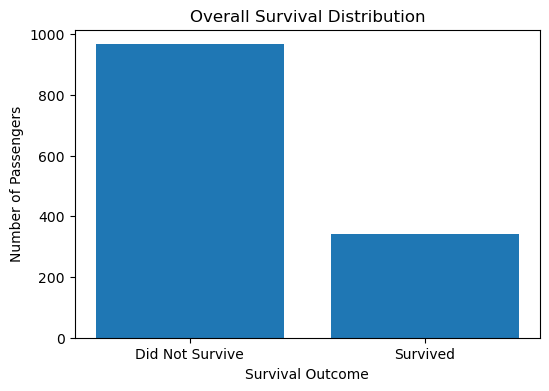

In [10]:
import matplotlib.pyplot as plt
survival_counts = data["Survived"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Did Not Survive", "Survived"], survival_counts.values)
plt.title("Overall Survival Distribution")
plt.ylabel("Number of Passengers")
plt.xlabel("Survival Outcome")
plt.show()

***Insight***:
- The dataset is imbalanced: 26% survived, 74% did not. This imbalance must inform model evaluation. Raw accuracy alone is misleading for imbalanced data. I will use AUC and F1-score instead of accuracy alone (see Phase 5 - Evaluation).

**Visualize class distribution of the target variable using Correlation heatmap**

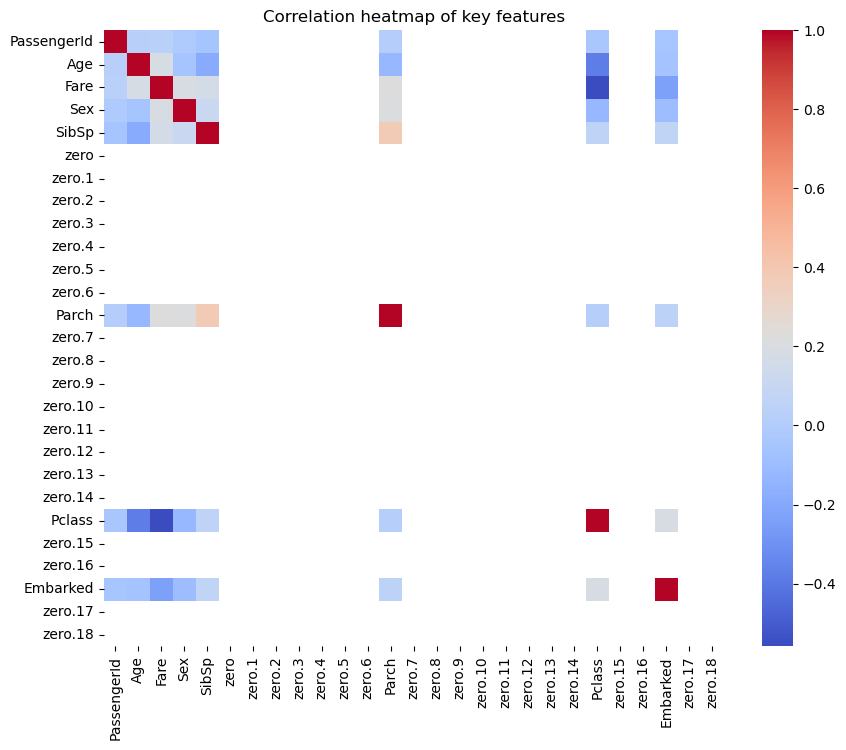

In [11]:
import seaborn as sns

# Prepare data for correlation analysis
x_data_val = data.drop(columns=["Survived"])
y_data_val = data["Survived"]

# Correlation heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(x_data_val.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation heatmap of key features")
plt.show()

***Insight:***
- The heatmap gives a quick overview of how numeric variables move together.
- `Pclass` and `Fare` show a noticeable negative relationship, which supports the idea that ticket fare reflects passenger class.
- `SibSp` and `Parch` show a mild positive relationship, which is expected because both describe family connections.
- `Age` shows weak linear correlation with most variables, so age effects are likely more complex and should be interpreted with class and gender context.
- Some columns (such as `zero.*`) create noise in the heatmap and reduce clarity. For cleaner interpretation, I will remove them and focus on core features (`Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, and encoded `Sex`/`Embarked`) in later analysis.
- Correlation helps with feature understanding, but it does not prove causation.

#### 3.2 Survival Distribution Across Passenger Classes

Next, I examine survival outcomes by passenger class.

Historically, evacuation on the Titanic followed a strong social hierarchy, where first-class passengers often had better access to lifeboats [8].

The visualization shows clear differences between passenger classes:
- First-class passengers have the highest survival counts.
- Second-class passengers show moderate survival rates.
- Third-class passengers have the lowest survival rates.
- This pattern supports historical accounts of class-based evacuation priorities.

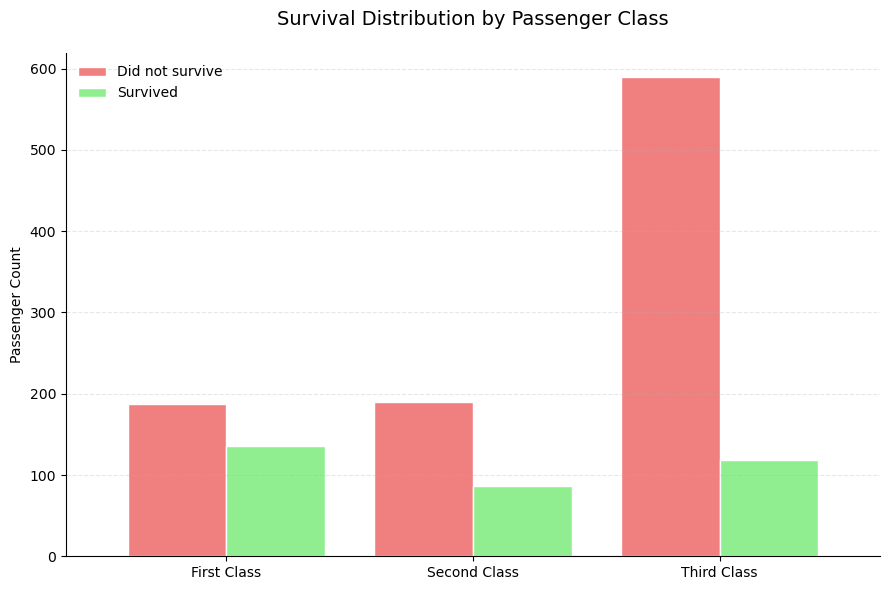

In [12]:
# 1. Mapping
map = {1: 'First Class', 2: 'Second Class', 3: 'Third Class'}
data['Pclass_Label'] = data['Pclass'].map(map)

# 2. Grouping and counting
survival_chart = (
    data.groupby(['Pclass_Label', 'Survived'], observed=True)
    .size()
    .unstack(fill_value=0)
)
survival_chart.columns = ['Did not survive', 'Survived']

# 3. Visualization 
fig, ax = plt.subplots(figsize=(9, 6))

survival_chart.plot(
    kind='bar', 
    ax=ax, 
    color=['lightcoral', 'lightgreen'],
    edgecolor='white',
    width=0.8
)

ax.set_title('Survival Distribution by Passenger Class', fontsize=14, pad=20)
ax.set_ylabel('Passenger Count')
ax.set_xlabel('') 
plt.xticks(rotation=0)
ax.legend(frameon=False)

ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()



***Insight***: 
- Third-class passengers experienced the lowest survival.
- This aligns with historical accounts of evacuation priority that prioritized wealthier first-class passengers [8].
- The chart shows that most passengers traveled in 3rd class, reflecting the socio-economic imbalance of the Titanic's passenger demographics [8].

#### 3.3 Survival Rate Distribution

To better quantify the differences between classes, I calculate survival rates.

The results show:
- First Class: ~42% survival rate
- Second Class: ~31% survival rate
- Third Class: ~17% survival rate

These numbers clearly show that passenger class had a strong influence on survival outcomes.

This finding supports the first research question (RQ1): passenger class appears to be an important feature for prediction.

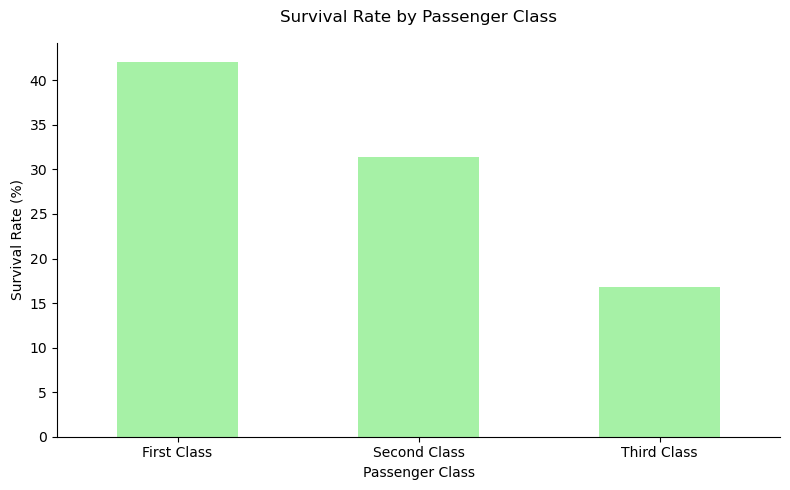

,Total Passengers,Survival Rate
Pclass_Label,,
First Class,323,42.105263
Second Class,277,31.407942
Third Class,709,16.784203


In [13]:
# Mapping
stats = data.groupby('Pclass_Label')['Survived'].agg(['count', 'mean'])

# Shaping for visualization
stats.columns = ['Total Passengers', 'Survival Rate']
stats['Survival Rate'] *= 100

fig, ax = plt.subplots(figsize=(8, 5))

stats['Survival Rate'].plot(kind='bar', ax=ax, color='lightgreen', alpha=0.8)

# Adding labels
ax.set_title('Survival Rate by Passenger Class', fontsize=12, pad=15)
ax.set_ylabel('Survival Rate (%)')
ax.set_xlabel('Passenger Class')
plt.xticks(rotation=0)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Display the stats DataFrame sorted by Survival Rate
stats.sort_values('Survival Rate', ascending=False)

***Insight***: 
- The Survival Rate of First Class is vastly higher than Third Class.
- **Direct answer to RQ1:** Yes. Passenger class clearly influenced survival in this dataset. First-class passengers had much higher survival chances than third-class passengers, based on both the class distribution chart and survival-rate chart.

#### 3.4 Survival by Gender

I then examine survival differences between male and female passengers.

Historical evidence suggests that evacuation followed the principle of “women and children first” [2], [6].

The analysis shows a large difference between genders:
- Female survival rate ≈ 50%
- Male survival rate ≈ 13%

This result strongly supports the historical narrative and confirms that gender is a key factor affecting survival.

In [14]:
# Count passengers by gender and survival
gender_survival = pd.crosstab(data['Sex'], data['Survived'])
gender_survival.columns = ['Did Not Survive', 'Survived']

print("Number of Passengers by Gender and Survival:")
print(gender_survival)

Number of Passengers by Gender and Survival:
     Did Not Survive  Survived
Sex                           
0                734       109
1                233       233


##### Gender Survival Rate Visualization

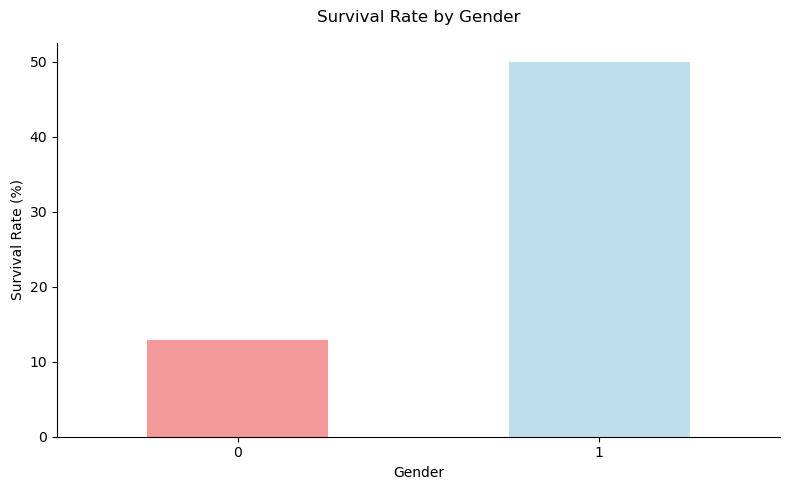


Survival Statistics by Gender:
     Total Passengers  Survival Rate
Sex                                 
0                 843          12.93
1                 466          50.00


In [15]:
# Calculate survival rate by gender
gender_stats = data.groupby('Sex')['Survived'].agg(['count', 'mean'])
gender_stats.columns = ['Total Passengers', 'Survival Rate']
gender_stats['Survival Rate'] = gender_stats['Survival Rate'] * 100

# Create visualization using matplotlib and subplots
fig, ax = plt.subplots(figsize=(8, 5))

gender_stats['Survival Rate'].plot(kind='bar', ax=ax, color=['lightcoral', 'lightblue'], alpha=0.8)

# Adding labels
ax.set_title('Survival Rate by Gender', fontsize=12, pad=15)
ax.set_ylabel('Survival Rate (%)')
ax.set_xlabel('Gender')
plt.xticks(rotation=0)
ax.spines[['top', 'right']].set_visible(False)

# show the plot
plt.tight_layout()
plt.show()

# Display the statistics
print("\nSurvival Statistics by Gender:")
print(gender_stats.round(2))

***Insight***: 
- Female passengers had a noticeably higher survival rate than male passengers.
- This supports the historical "women and children first" evacuation priority that was practiced during the Titanic disaster [2][6].
- Gender was clearly a significant factor influencing who survived, making it an important feature to include in our model.
- **Direct answer to RQ4:** Yes, the data supports a gender priority pattern. Female passengers had a much higher survival rate than male passengers, which is consistent with the historical "women and children first" evacuation narrative.

#### 3.5 Age Distribution by passenger class and survival outcome

Next, I analyze the age distribution of passengers.

The dataset includes passengers ranging from infants to elderly individuals, with ages between approximately 0.17 and 80 years.

Exploring survival across age groups shows that younger passengers often had better survival chances, although the pattern varies depending on passenger class [6].

This suggests that age plays a role in survival, but its effect interacts with other factors such as class and gender.

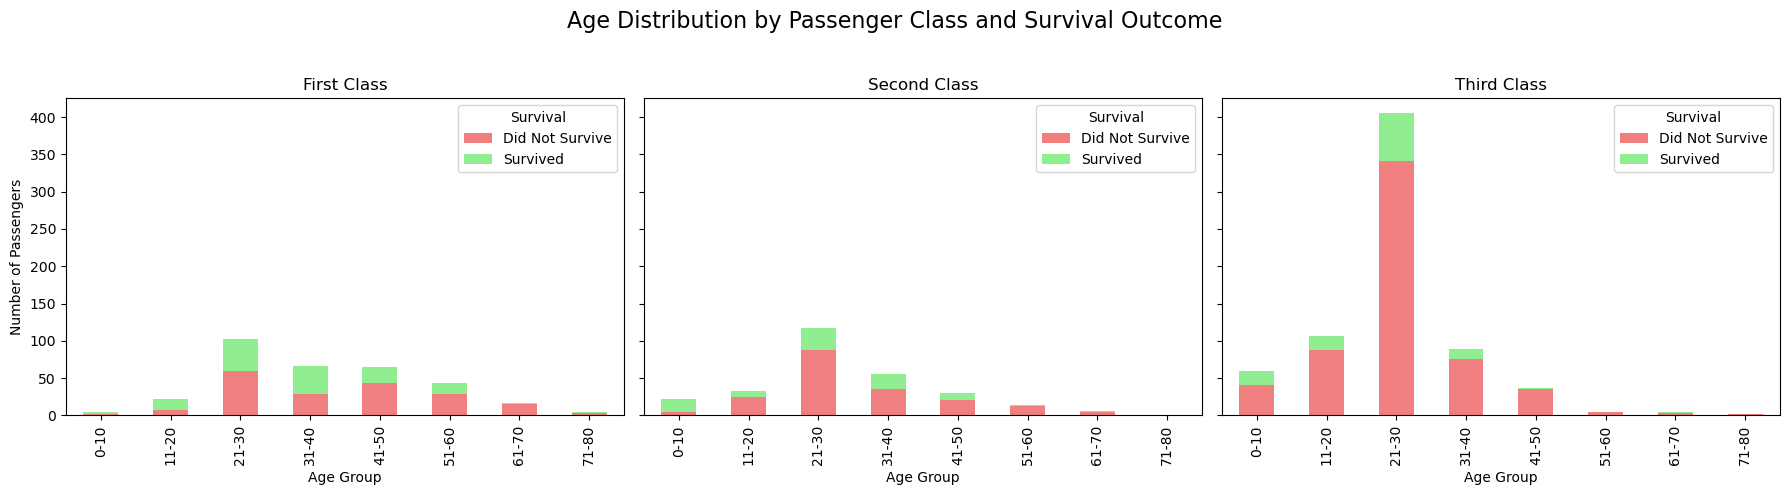

In [16]:
# Prepare the temp data
temp = data.copy()
temp["Pclass_Label"] = temp["Pclass"].map({1: "First Class", 2: "Second Class", 3: "Third Class"})
temp["Survival_Label"] = temp["Survived"].map({0: "Did Not Survive", 1: "Survived"})

# Create age bins
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ["0-10","11-20","21-30","31-40","41-50","51-60","61-70","71-80"]
temp["Age_Bin"] = pd.cut(temp["Age"], bins=age_bins, labels=age_labels, include_lowest=True)

# Prepare plot
classes = ["First Class", "Second Class", "Third Class"]
colors = {"Did Not Survive": "lightcoral", "Survived": "lightgreen"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, cls in enumerate(classes):
    ax = axes[i]
    subset = temp[temp["Pclass_Label"] == cls]
    counts = subset.groupby(["Age_Bin", "Survival_Label"], observed=False)["PassengerId"].count().unstack(fill_value=0)
    counts.plot(kind="bar", stacked=True, color=[colors[col] for col in counts.columns], ax=ax)
    ax.set_title(cls)
    ax.set_xlabel("Age Group")
    if i == 0:
        ax.set_ylabel("Number of Passengers")
    ax.legend(title="Survival", loc="upper right")

fig.suptitle("Age Distribution by Passenger Class and Survival Outcome", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Insight**: 

- A std of 12.9 is moderate to high relative to the mean. This indicates that passenger ages are fairly spread out - there are children, adults, and elderly passengers, not just a narrow age group.
- The min = 0.17 and max = 80 also shows wide age range (babies to elderly).
- **Direct answer to RQ2:** Partly yes. Younger passengers appear to have better survival in several groups, but the pattern is not identical across all classes. This means age matters, but class context also matters.

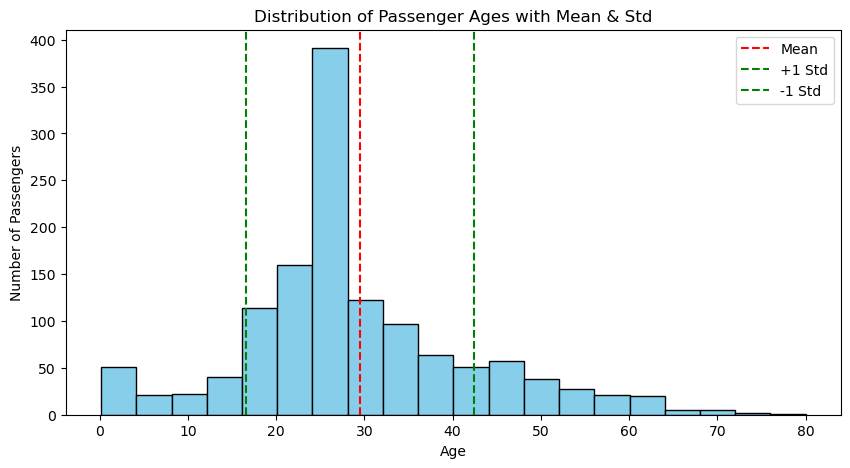

In [17]:
plt.figure(figsize=(10,5))
plt.hist(data["Age"].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.axvline(data["Age"].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(data["Age"].mean() + data["Age"].std(), color='green', linestyle='--', label='+1 Std')
plt.axvline(data["Age"].mean() - data["Age"].std(), color='green', linestyle='--', label='-1 Std')
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passenger Ages with Mean & Std")
plt.legend()
plt.show()

#### 3.6 Survival by Family size

I also examine whether traveling with family affected survival.

To study this, I create a new feature called Family_Size, which combines the number of siblings/spouses (SibSp) and parents/children (Parch) traveling with the passenger.

This feature reflects the total number of family members aboard the ship.

The analysis shows that:
- Small families (1–3 members) often had better survival outcomes.
- Passengers traveling alone had lower survival rates and very large families also had lower survival chances.

This suggests that family size influenced evacuation outcomes.

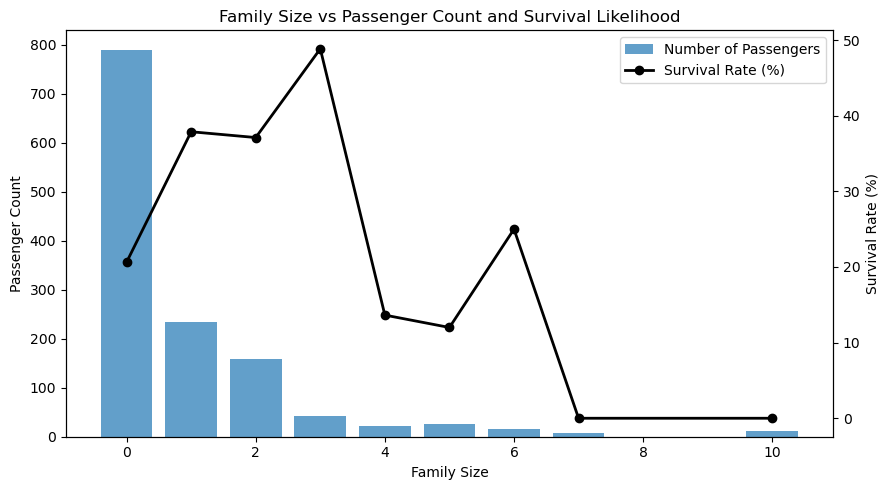

In [18]:
# Create a new column for family size
temp = data.copy()
temp["Family_Size"] = temp["SibSp"] + temp["Parch"]

# Prepare data
stats = (
    temp
    .groupby("Family_Size")["Survived"]
    .agg(["count", "mean"])
)

stats["Survival_Rate"] = stats["mean"] * 100

# Create combined bar and line chart
fig, ax1 = plt.subplots(figsize=(9,5))

# Bar chart: passenger count
bars = ax1.bar(
    stats.index,
    stats["count"],
    alpha=0.7,
    label="Number of Passengers"
)
ax1.set_xlabel("Family Size")
ax1.set_ylabel("Passenger Count")

# Line chart: survival rate
ax2 = ax1.twinx()
line = ax2.plot(
    stats.index,
    stats["Survival_Rate"],
    marker="o",
    linewidth=2,
    color="black",
    label="Survival Rate (%)"
)
ax2.set_ylabel("Survival Rate (%)")

# Combine legends from both axes
handles = bars, line[0]
labels = ["Number of Passengers", "Survival Rate (%)"]
ax1.legend(handles, labels, loc="upper right")

# Title
plt.title("Family Size vs Passenger Count and Survival Likelihood")
plt.tight_layout()
plt.show()

***Insight***:
- **Direct answer to RQ3:** Traveling together had a mixed effect. Small family groups (about 1-3 members) had better survival outcomes, while solo travelers and very large families had lower survival. This suggests family size influenced evacuation outcomes.

**Trade-off Note (Family features):**  
I created `Family_Size` from `SibSp + Parch` to capture family group behavior in one simple feature. The benefit is simpler analysis and clearer storytelling. 

The downside is that I lose some detail about relationship type (siblings/spouse vs. parent/child).  
To reduce this risk, I still keep the original columns for possible use in modeling.

#### 3.7 Family Relationships Analysis

I further examine the individual family features (SibSp and Parch) to understand their effect on survival.

These variables provide more detailed information about passenger relationships.

Because both variables contain useful information, I decide to:

- Keep the original variables
- Also use the combined Family_Size feature for modeling

This approach preserves detailed information while capturing overall family group effects.

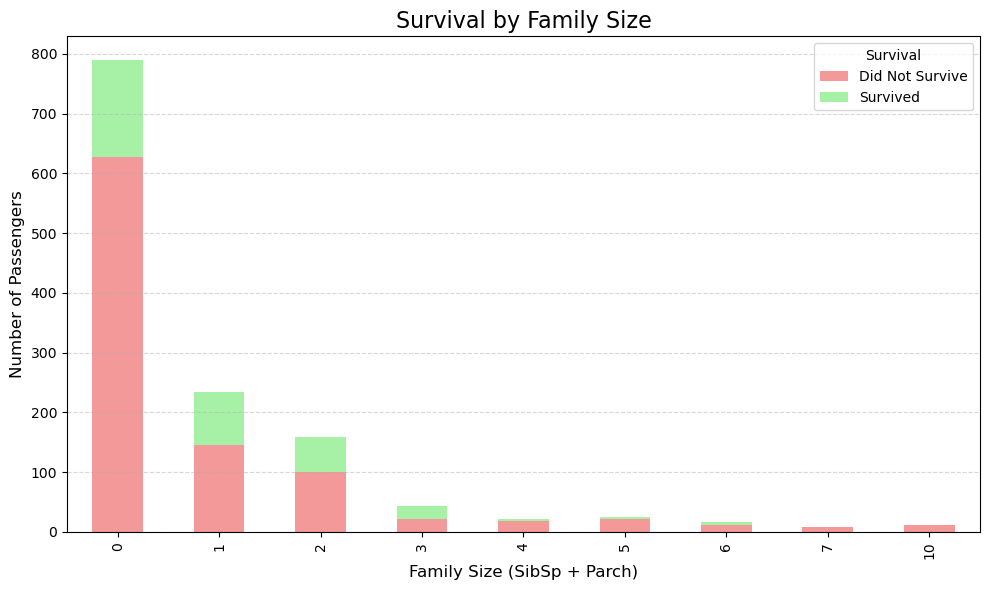

In [19]:
# Prepare temp data
temp["Survival_Label"] = temp["Survived"].map({0: "Did Not Survive", 1: "Survived"})

# Group data by family size and survival
family_counts = temp.groupby(["Family_Size", "Survival_Label"])["PassengerId"].count().unstack(fill_value=0)

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10,6))
family_counts.plot(kind="bar", stacked=True, color=["lightcoral", "lightgreen"], alpha=0.8, ax=ax)

# Titles and labels
ax.set_title("Survival by Family Size", fontsize=16)
ax.set_xlabel("Family Size (SibSp + Parch)", fontsize=12)
ax.set_ylabel("Number of Passengers", fontsize=12)
ax.legend(title="Survival", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


A stacked bar chart shows the number of passengers in each family size category and whether they survived or not.

***Insight***: 
- Passengers with small families (1-3 members) had higher survival chances.
- Solo passengers (Family_Size = 0) and very large families had lower survival.
- Since SibSp and Parch provide deep insight into survival rate, my decision is to keep and create a new feature called "Family_size"

#### 3.8 Survival Rate Across Fare Categories

Ticket fare is another important variable because it reflects passenger economic status.

However, fare values are highly skewed. To make analysis easier to interpret, I group fares into four categories using quantile-based binning:
- Low Fare
- Medium Fare
- High Fare
- Very High Fare

Quantile binning ensures that each category contains a similar number of passengers, which is a common approach in exploratory analysis [4].

The results show that higher fare groups tend to have higher survival rates.

This pattern likely reflects the relationship between ticket fare and passenger class.

Based on the dataset:
- **Low Fare** passengers paid approximately ≤ 7.90
- **Medium Fare** passengers paid between 7.90 and 14.45
- **High Fare** passengers paid between 14.45 and 31.28
- **Very High Fare** passengers paid more than 31.28

This categorization allows clearer comparison of survival outcomes across socio-economic groups.


Fare Bracket | Avg. Amount Paid | Survival Rate
--------------------------------------------------
                Avg_Amount_Paid  Survival_Rate
Fare_Bracket                                  
Low Fare                   7.16          13.06
Medium Fare               10.53          21.18
High Fare                 23.03          30.79
Very High Fare            93.55          39.94


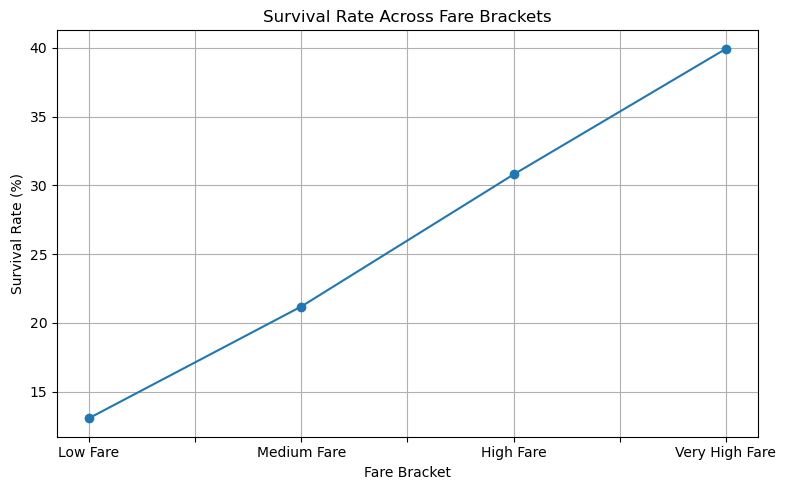

In [20]:
# Create fare bracket using quantiles
temp = data.copy()
temp["Fare_Bracket"] = pd.qcut(
    temp["Fare"],
    q=4,
    labels=["Low Fare", "Medium Fare", "High Fare", "Very High Fare"]
)

# I calculate the average amount paid and the survival percentage in one step
summary = temp.groupby('Fare_Bracket', observed=True)['Survived'].agg(
    Avg_Amount_Paid='mean',
    Survival_Rate='mean'
)

# I adjust the Fare column to show the average (mean) amount paid for each fare category
summary['Avg_Amount_Paid'] = temp.groupby('Fare_Bracket',observed=False)['Fare'].mean()
summary['Survival_Rate'] = (summary['Survival_Rate'] * 100).round(2)

print("Fare Bracket | Avg. Amount Paid | Survival Rate")
print("-" * 50)
print(summary.round(2))

# Survival rate per fare band
fare_survival = temp.groupby("Fare_Bracket", observed=True)["Survived"].mean() * 100

# Plot
plt.figure(figsize=(8,5))
fare_survival.plot(marker="o")

plt.xlabel("Fare Bracket")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate Across Fare Brackets")
plt.grid(True)
plt.tight_layout()
plt.show()



**Insights:**
- Higher fare groups show higher survival rates.
- Fare likely reflects passenger class and economic status.
- The data relationship appears consistent, but further modeling is needed to confirm predictive strength.

**Trade-off Note (Fare Bracket):**  
I used fare bracket instead of raw fare values. The benefit is easier interpretation of low, medium, high, and very high fare groups.  

The downside is some loss of detailed numeric information. I accepted this because the project goal includes explainable insights, not only raw model complexity.

### 4. Verify Data Quality

Before moving to the data preparation phase, I conduct a data quality audit.

This step helps ensure that the dataset is reliable and suitable for modeling.

The main checks include:

- Column name consistency (Normalization)
- Missing values
- Data types
- Duplicate rows
- Outliers
- Logical value ranges
- Unique identifiers  

#### 4.1: Normalize column names
Consistency in naming conventions (CamelCase) prevents coding errors during the "Realization" phase. This is a standard practice in software engineering to maintain clean, readable code.

In [21]:
# Step 1: Normalize column names
data = data.rename(columns={    
    "Passengerid": "PassengerId",
    "sibsp": "SibSp",
    "2urvived": "Survived",  # Fix spelling
    "parch": "Parch",
    "pclass": "Pclass",
    "fare": "Fare",
    "age": "Age"
})

# Step 1b: Filter out unnecessary columns starting with 'zero'
data = data[[col for col in data.columns if not col.lower().startswith("zero")]]

data.head()

,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived,Pclass_Label
0,1,22.0,7.2500,0,1,0,3,2.0,0,Third Class
1,2,38.0,71.2833,1,1,0,1,0.0,1,First Class
2,3,26.0,7.9250,1,0,0,3,2.0,1,Third Class
3,4,35.0,53.1000,1,1,0,1,2.0,1,First Class
4,5,35.0,8.0500,0,0,0,3,2.0,0,Third Class


#### 4.2: Checking for missing values
I am identifying "Missing at Random" (MAR) data. For instance, if Age is missing, I cannot simply delete those rows, as it might remove a specific demographic (like 3rd class passengers) and bias the model [3].

My approach of using median imputation for Age follows common practice when data appear to be missing.

In [22]:
# Missing values table
missing_values = pd.DataFrame({
    "Missing Values Found": ["Yes" if data[col].isnull().sum() > 0 else "No" for col in data.columns],
    "Count": [data[col].isnull().sum() for col in data.columns]
}, index=data.columns)

missing_values

,Missing Values Found,Count
PassengerId,No,0
Age,No,0
Fare,No,0
Sex,No,0
SibSp,No,0
Parch,No,0
Pclass,No,0
Embarked,Yes,2
Survived,No,0
Pclass_Label,No,0


#### 4.3: Confirming correct data types

In this step, I am verifying that categorical numbers (like Pclass) are not being treated as continuous floats, which would lead to a mathematically incorrect model.

In [23]:
# Data types
data_summary = pd.DataFrame({
    "Data Type": [data[col].dtype for col in data.columns]
}, index=data.columns)

data_summary

,Data Type
PassengerId,int64
Age,float64
Fare,float64
Sex,int64
SibSp,int64
Parch,int64
Pclass,int64
Embarked,float64
Survived,int64
Pclass_Label,object


#### 4.4: Detecting duplicate rows
Duplicate data can lead to "data leakage," where the model "memorizes" certain passengers rather than learning general patterns. Removing them is essential for valid cross-validation.

In [24]:
# Find duplicate rows
duplicates = data.duplicated()
num_of_duplicates = duplicates.sum()
if num_of_duplicates > 0:
    print(f"Warning: Found {num_of_duplicates} duplicate rows in the dataset.")
else :
    print("No duplicate rows found in the dataset.")

No duplicate rows found in the dataset.


#### 4.5: Identifying outliers
I am using the Interquartile Range (IQR) method. This is a robust statistical method that is less sensitive to extreme values than the Z-score, making it ideal for skewed data like the Titanic's Fare column [7].

In [25]:
# columns
cols = ["Age", "Fare", "Sex", "SibSp", "Parch", "Pclass", "Embarked", "Survived"]

# Outlier detection using IQR method
outlier_summary = []

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)][col].count()
    outlier_summary.append([col, "Yes" if outliers > 0 else "No", outliers])

outlier_summary_count = pd.DataFrame(outlier_summary, columns=["Column", "Outliers Found", "Count"])

outlier_summary_count

,Column,Outliers Found,Count
0,Age,Yes,101
1,Fare,Yes,171
2,Sex,No,0
3,SibSp,Yes,57
4,Parch,Yes,307
5,Pclass,No,0
6,Embarked,No,0
7,Survived,No,0


#### 4.6: Verifying consistency and valid ranges
I am checking for "impossible" values, such as negative ages or fares. This ensures the data is logically sound.

In [26]:
# Define categorical columns
categorical_columns = ["Survived", "Pclass", "Sex", "Embarked"]

# Prepare summary rows
rows = []

for col in categorical_columns:
    col_dtype = data[col].dtype  # actual dtype
    for val, count in data[col].value_counts().items():
        rows.append({
            "Column": col,
            "Possible Value": str(val),
            "dtype": col_dtype,
            "Count": count
        })

# Convert to DataFrame
cat_summary_df = pd.DataFrame(rows)

# Sort by Column for readability
cat_summary_df = cat_summary_df.sort_values(by="Column").reset_index(drop=True)

cat_summary_df


,Column,Possible Value,dtype,Count
0,Embarked,2.0,float64,914
1,Embarked,0.0,float64,270
2,Embarked,1.0,float64,123
3,Pclass,3,int64,709
4,Pclass,1,int64,323
5,Pclass,2,int64,277
6,Sex,0,int64,843
7,Sex,1,int64,466
8,Survived,0,int64,967
9,Survived,1,int64,342


#### 4.7: Ensuring unique identifiers
I am verifying that the PassengerId is truly unique. This confirms that each row represents a distinct individual and there are no errors in the data collection process.

In [27]:
# Step 7: Ensure PassengerId is Unique
unique_passenger_ids = data["PassengerId"].is_unique
if unique_passenger_ids:
    print("PassengerId is unique across all rows.")
else :
    print("Warning: PassengerId is not unique. Please check for duplicates.")

PassengerId is unique across all rows.


#### 4.8: Numeric Distribution
Using boxplots, I can visually confirm the distribution of my variables. This step is vital for deciding whether I need to use "Log Transformations" in the data preparation phase to handle highly skewed features like Fare.

I use boxplots to visualize the distributions of numeric columns in the dataset. Each box shows:

- **Median (line inside the box)** – the middle value of the data.
- **Interquartile Range (IQR, box edges)** – the middle 50% of the data.
- **Whiskers** – typically 1.5 times the IQR, representing the expected range.
- **Outliers (points outside whiskers)** – extreme values that are unusually high or low.

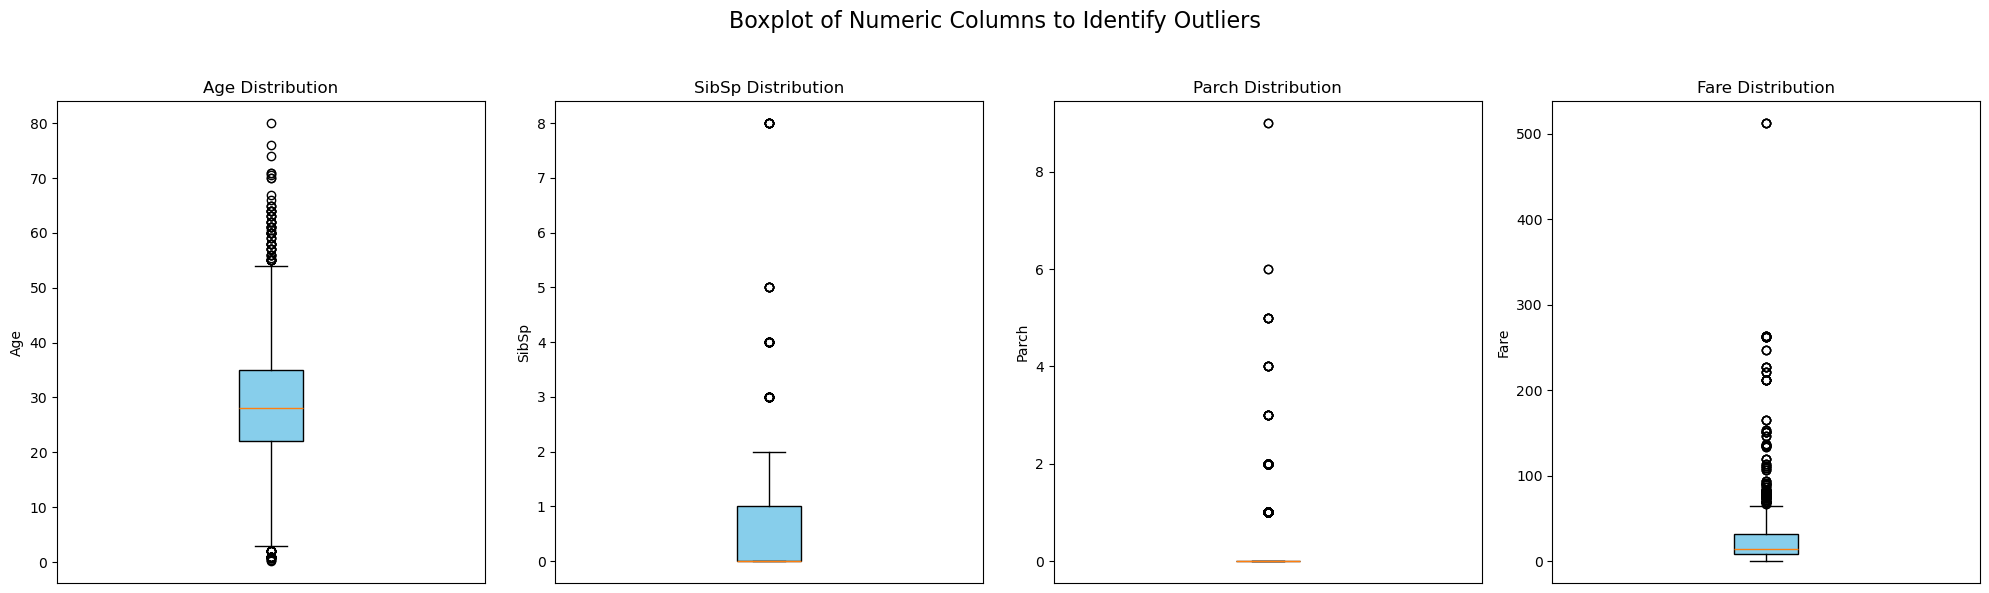

In [28]:
# Step 8: Visualize numeric distributions using Boxplots
numeric_cols = ["Age", "SibSp", "Parch", "Fare"]

# Set up figure
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 6))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(data[col].dropna(), patch_artist=True, boxprops=dict(facecolor="skyblue"))
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_ylabel(col)
    axes[i].set_xticks([])  # Remove x-axis tick for clarity

plt.suptitle("Boxplot of Numeric Columns to Identify Outliers", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Insights:**
- `Age`: Some passengers are much older or younger than the majority (outliers present).
- `SibSp` & `Parch`: Most passengers travel alone or with 1–2 family members; a few have large families.
- `Fare`: Highly skewed with a few very high fares indicating wealthier passengers.

#### 4.9: Evidence check for Embarked contribution
This steps help me validate if excluding Embarked is required before commencing Phase 3, Basically, I validate whether embarkation should be part of the **baseline** feature set.

In [29]:
# Step 9: Evidence check for Embarked contribution
evidence_df = data.copy()

# Harmonize key column names for robust analysis
rename_map = {"Passengerid": "PassengerId", "2urvived": "Survived", "sibsp": "SibSp"}
evidence_df = evidence_df.rename(columns={k: v for k, v in rename_map.items() if k in evidence_df.columns})

# Defining the categorical columns for evidence check
required_cols = ["Survived", "Embarked", "Pclass", "Sex", "Fare"]
missing_cols = [c for c in required_cols if c not in evidence_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for evidence check: {missing_cols}")

# Normalize types
evidence_df["Survived"] = pd.to_numeric(evidence_df["Survived"], errors="coerce")
evidence_df["Embarked"] = pd.to_numeric(evidence_df["Embarked"], errors="coerce")
evidence_df["Pclass"] = pd.to_numeric(evidence_df["Pclass"], errors="coerce")
evidence_df["Fare"] = pd.to_numeric(evidence_df["Fare"], errors="coerce")
evidence_df["Sex"] = evidence_df["Sex"].astype(str).str.strip().str.lower()
evidence_df["Sex"] = evidence_df["Sex"].replace({"0": "male", "1": "female"})

# Keep rows usable for comparison
check_df = evidence_df.dropna(subset=["Survived", "Embarked", "Pclass", "Sex", "Fare"]).copy()
check_df = check_df[check_df["Survived"].isin([0, 1])]

# Survival by Embarked
embarked_summary = check_df.groupby("Embarked")["Survived"].agg(["count", "mean"]).sort_index()
embarked_summary["mean"] = embarked_summary["mean"].round(3)
embarked_range = float(embarked_summary["mean"].max() - embarked_summary["mean"].min())

# Survival ranges for stronger features
pclass_range = float(check_df.groupby("Pclass")["Survived"].mean().max() - check_df.groupby("Pclass")["Survived"].mean().min())
sex_range = float(check_df.groupby("Sex")["Survived"].mean().max() - check_df.groupby("Sex")["Survived"].mean().min())
check_df["Fare_Bin"] = pd.qcut(check_df["Fare"], q=4, duplicates="drop")
fare_range = float(check_df.groupby("Fare_Bin", observed=False)["Survived"].mean().max() - check_df.groupby("Fare_Bin", observed=False)["Survived"].mean().min())

print("Survival by Embarked (count + rate):")
print(embarked_summary)
print("\nSurvival-rate range by feature:")
print({
    "Embarked_range": round(embarked_range, 3),
    "Pclass_range": round(pclass_range, 3),
    "Sex_range": round(sex_range, 3),
    "Fare_range": round(fare_range, 3),
})

if embarked_range < min(pclass_range, sex_range, fare_range):
    print("\nConclusion: Embarked appears weaker than core predictors; excluding Embarked_Code from baseline preparation is justified.")
else:
    print("\nConclusion: Embarked has non-trivial signal; keep excluded for baseline simplicity, but re-test during modeling.")

Survival by Embarked (count + rate):
          count   mean
Embarked              
0.0         270  0.344
1.0         123  0.244
2.0         914  0.237

Survival-rate range by feature:
{'Embarked_range': 0.107, 'Pclass_range': 0.25, 'Sex_range': 0.369, 'Fare_range': 0.265}

Conclusion: Embarked appears weaker than core predictors; excluding Embarked_Code from baseline preparation is justified.


**Insight**:
- Embarked shows only limited incremental pattern compared with stronger predictors (class, sex, fare), I exclude it from the baseline model inputs.
- I'll keep the cleaned `Embarked` column for traceability and possible re-testing in the modeling phase.

#### 4.10 Normalization Decision

Based on the feature range/distribution checks in this notebook, normalization is not required for the baseline preparation workflow.

**Why**?
- Most core features are already in small or discrete ranges (`Pclass`, `SibSp`, `Parch`) or will be encoded as binary (`Sex`).
- `Fare` is right-skewed, but this is addressed through fare grouping (`Fare_Bracket`) for interpretability.
- The current objective is explainable baseline modeling, so keeping original units is acceptable.

**Decision:** I'll not apply normalization in this phase.

### Conclusion

The data understanding phase provides several important insights.

First, the dataset is generally clean and suitable for analysis, although some feature engineering will be required.

Secondly, several variables show clear relationships with survival:
- Passenger class
- Gender
- Age
- Family size
- Ticket fare

These patterns support historical research about the Titanic disaster.

The findings also guide the next phase of the project:
- Fare may require grouping or scaling due to skewness.
- The Family_Size feature should be included in the model.
- Embarked appears weaker than other predictors and may be excluded from the baseline model.

Overall, this phase provides the evidence needed to prepare the dataset for machine learning in the next stage of the CRISP-DM process.

### References
- [1] Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). CRISP-DM 1.0: Step-by-step data mining guide.
- [2] B. S. Frey, D. A. Savage, and B. Torgler, "Behavior under extreme conditions: The Titanic disaster," Journal of Economic Perspectives, vol. 25, no. 1, pp. 209–222, 2011.
- [3] G. James, D. Witten, T. Hastie, and R. Tibshirani, An Introduction to Statistical Learning: with Applications in R, 2nd ed. New York, NY: Springer, 2021.
- [4] J. W. Tukey, Exploratory Data Analysis. Reading, MA: Addison-Wesley, 1977.
- [5] W. McKinney, "Data Structures for Statistical Computing in Python," in Proceedings of the 9th Python in Science Conference, 2010, pp. 56–61.
- [6] D. Gleicher, "The Rescue of the Titanic Survivors," J. Soc. Hist., vol. 40, no. 1, pp. 157–178, 2006.
- [7] B. Iglewicz and D. C. Hoaglin, How to Detect and Handle Outliers. Milwaukee, WI: ASQC Quality Press, 1993.
- [8] D. A. Butler, Unsinkable: The Full Story of the RMS Titanic, Mechanicsburg, PA, USA: Stackpole Books, 1998.
- [9] He, H., & Garcia, E.A. (2009). "Learning from Imbalanced Data." IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284.
- [10] Rubin, D.B. (1987). Multiple Imputation for Nonresponse in Surveys. John Wiley & Sons.